# First Wave — Student Dropout Prediction

This notebook is all about predicting student dropping out of high scool as early as possible (9th grade).

We're training **multiple models** across two datasets: a 'baseline' dataset with all features and an 'enhanced' one with additional feature-selected variables.

We'll be looking closely at **Recall** (how many actual dropouts we catch).

## Imports

In [6]:
!pip install xgboost lightgbm shap -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import (    train_test_split, StratifiedKFold, cross_val_score,    RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (    classification_report, roc_auc_score, roc_curve,    confusion_matrix, f1_score, precision_score, recall_score,    accuracy_score, precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Helper — Evaluation Function

This `evaluate()` function (defined in the next cell) is super handy. After each model runs, we'll call it to print out all the key metrics and save them. This makes it easy to compare models later on.

In [8]:
# We'll collect every model's results here so we can build a summary table at the end
results = []

# Separate storage for arrays — keeps the results table clean
predictions_store = {}


def evaluate(model_name, y_true, y_pred, y_prob, threshold=0.50):
    """
    Prints all evaluation metrics for a single model and saves them to `results`.

    Parameters
    ----------
    model_name : str
        Label used in the results table
    y_true : array
        Actual labels from the test set
    y_pred : array
        Predicted labels (after applying the threshold)
    y_prob : array
        Predicted probability of dropout (class 1)
    threshold : float
        Decision threshold used to turn probabilities into labels
    """
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    precision = precision_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    print("=" * 60)
    print(f"  {model_name}")
    print(f"  Threshold used : {threshold:.2f}")
    print("=" * 60)
    print(f"  Recall    : {recall:.4f}   <-- fraction of real dropouts we caught")
    print(f"  F1-Score  : {f1:.4f}   <-- balance between precision and recall")
    print(f"  ROC-AUC   : {roc_auc:.4f}   <-- ranking ability across all thresholds")
    print(f"  Precision : {precision:.4f}")
    print(f"  Accuracy  : {accuracy:.4f}   (not very meaningful here — classes are imbalanced)")
    print(f"  TP: {tp}  FN: {fn}  FP: {fp}  TN: {tn}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Not Dropout", "Dropout"]))

    # Store metrics only (no large arrays) for the summary table
    results.append({
        "Model": model_name,
        "Threshold": threshold,
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4),
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "TN": tn,
    })

    # Store arrays separately for later use in plots
    predictions_store[model_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

    return recall, f1, roc_auc


print("evaluate() is ready.")

evaluate() is ready.


## Part 1 — Baseline Dataset (50 features)

First, we load up our main dataset, `Baseline_Dataset50.csv`. The code checks how many students dropped out versus how many didn't.

In [9]:
df_base = pd.read_csv('Baseline_Dataset50.csv')

TARGET = 'X4EVERDROP'

# Quick sanity check — make sure the target column is actually in there
assert TARGET in df_base.columns, (
    f"Couldn't find '{TARGET}' in the dataset. "
    f"Columns available: {df_base.columns.tolist()}"
)

print(f'Rows    : {df_base.shape[0]:,}')
print(f'Columns : {df_base.shape[1]}')
print(f'Missing : {df_base.isnull().sum().sum()} cells')

n_dropout    = int(df_base[TARGET].sum())
n_no_dropout = len(df_base) - n_dropout
n_total      = len(df_base)

print(f'\nNot Dropout : {n_no_dropout:,}  ({100*n_no_dropout/n_total:.1f}%)')
print(f'Dropout     : {n_dropout:,}  ({100*n_dropout/n_total:.1f}%)')
print(f'Imbalance   : {n_no_dropout/n_dropout:.1f}:1  (the minority class is dropout)')

Rows    : 15,900
Columns : 50
Missing : 0 cells

Not Dropout : 13,457  (84.6%)
Dropout     : 2,443  (15.4%)
Imbalance   : 5.5:1  (the minority class is dropout)


In [10]:
# --- Class weights ---
# The dataset is imbalanced (~5.5 non-dropouts for every 1 dropout).
# Instead of resampling, we tell the models to penalise dropout misclassifications
# more heavily using class weights.
#
# Formula: weight_k = total_samples / (2 * count_k)

w0_base = n_total / (2 * n_no_dropout)   # weight for class 0 (not dropout)
w1_base = n_total / (2 * n_dropout)      # weight for class 1 (dropout)
class_weights_base = {0: w0_base, 1: w1_base}

# XGBoost uses a single ratio instead of per-class weights
scale_pos_weight_base = n_no_dropout / n_dropout

print('Class weights (for sklearn models):')
print(f'  Not Dropout (0) : {w0_base:.4f}')
print(f'  Dropout     (1) : {w1_base:.4f}')
print(f'  => Each dropout sample is treated as {w1_base:.2f}x a non-dropout during training')
print(f'\nscale_pos_weight (for XGBoost/LightGBM): {scale_pos_weight_base:.4f}')

Class weights (for sklearn models):
  Not Dropout (0) : 0.5908
  Dropout     (1) : 3.2542
  => Each dropout sample is treated as 3.25x a non-dropout during training

scale_pos_weight (for XGBoost/LightGBM): 5.5084


Training set : 12,720 samples
Test set     : 3,180 samples


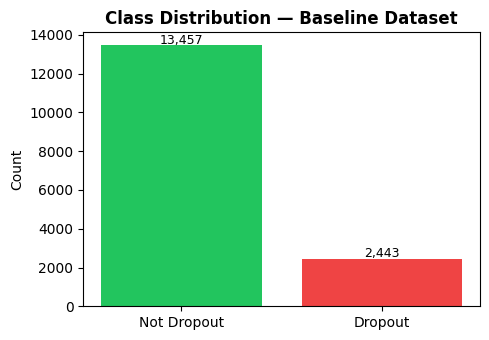

In [11]:
# --- Features and labels ---
FEATURES_BASE = [col for col in df_base.columns if col != TARGET]
X_base = df_base[FEATURES_BASE].values
y_base = df_base[TARGET].values

# --- Train / test split ---
# stratify=y_base keeps the same dropout ratio in both sets
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_base, y_base,
    test_size=0.20,
    random_state=42,
    stratify=y_base
)

# --- Scale features ---
# We fit the scaler only on training data to avoid data leakage.
scaler_base = StandardScaler()
X_tr_b_sc = scaler_base.fit_transform(X_tr_b)
X_te_b_sc = scaler_base.transform(X_te_b)

print(f'Training set : {len(X_tr_b):,} samples')
print(f'Test set     : {len(X_te_b):,} samples')

# Plot the class distribution so we can see the imbalance visually
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Not Dropout', 'Dropout'], [n_no_dropout, n_dropout],
       color=['#22c55e', '#ef4444'], edgecolor='none')
ax.set_title('Class Distribution — Baseline Dataset', fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(ax.patches, [n_no_dropout, n_dropout]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80, f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Baseline Model 1 — Logistic Regression

We're starting with Logistic Regression. It's a straightforward model that helps us understand if our more complex models are actually doing better. The code in the next cell trains this model, makes predictions, and then uses our `evaluate()` function to show us the results.

In [12]:
print('Training Baseline 1 — Logistic Regression ...')

lr_base = LogisticRegression(
    # class_weight=class_weights_base, # Removed for this version
    max_iter=1000,
    random_state=42
)
lr_base.fit(X_tr_b_sc, y_tr_b)

y_pred_lr_b = lr_base.predict(X_te_b_sc)
y_prob_lr_b = lr_base.predict_proba(X_te_b_sc)[:, 1]

evaluate('Baseline 1 — Logistic Regression', y_te_b, y_pred_lr_b, y_prob_lr_b)

Training Baseline 1 — Logistic Regression ...
  Baseline 1 — Logistic Regression
  Threshold used : 0.50
  Recall    : 0.1370   <-- fraction of real dropouts we caught
  F1-Score  : 0.2190   <-- balance between precision and recall
  ROC-AUC   : 0.7835   <-- ranking ability across all thresholds
  Precision : 0.5447
  Accuracy  : 0.8497   (not very meaningful here — classes are imbalanced)
  TP: 67  FN: 422  FP: 56  TN: 2635

              precision    recall  f1-score   support

 Not Dropout       0.86      0.98      0.92      2691
     Dropout       0.54      0.14      0.22       489

    accuracy                           0.85      3180
   macro avg       0.70      0.56      0.57      3180
weighted avg       0.81      0.85      0.81      3180



(0.13701431492842536, 0.21895424836601307, np.float64(0.7834932620208693))

### Baseline Model 2 — Random Forest

Next up is a Random Forest. These models are great at finding tricky patterns and interactions in the data. The cell below sets up, trains, and evaluates this model, just like with Logistic Regression.

In [13]:
print('Training Baseline 2 — Random Forest ...')

rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    # class_weight=class_weights_base, # Removed for this version
    random_state=42,
    n_jobs=-1        # use all CPU cores
)
rf_base.fit(X_tr_b_sc, y_tr_b)

y_pred_rf_b = rf_base.predict(X_te_b_sc)
y_prob_rf_b = rf_base.predict_proba(X_te_b_sc)[:, 1]

evaluate('Baseline 2 — Random Forest', y_te_b, y_pred_rf_b, y_prob_rf_b)

Training Baseline 2 — Random Forest ...
  Baseline 2 — Random Forest
  Threshold used : 0.50
  Recall    : 0.0736   <-- fraction of real dropouts we caught
  F1-Score  : 0.1328   <-- balance between precision and recall
  ROC-AUC   : 0.7838   <-- ranking ability across all thresholds
  Precision : 0.6792
  Accuracy  : 0.8522   (not very meaningful here — classes are imbalanced)
  TP: 36  FN: 453  FP: 17  TN: 2674

              precision    recall  f1-score   support

 Not Dropout       0.86      0.99      0.92      2691
     Dropout       0.68      0.07      0.13       489

    accuracy                           0.85      3180
   macro avg       0.77      0.53      0.53      3180
weighted avg       0.83      0.85      0.80      3180



(0.0736196319018405, 0.13284132841328414, np.float64(0.7837736786789867))

### Baseline Model 3 — XGBoost

XGBoost is a powerful gradient boosting model that builds trees one after another, learning from past mistakes. The code below trains it and, importantly, evaluates it at two different prediction thresholds (0.50 and 0.30). Why two? Because sometimes we want to catch *more* potential dropouts, even if it means a few false alarms. In education, catching at-risk students early is key!

In [14]:
print('Training Baseline 3 — XGBoost ...')

xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,           # use 80% of rows per tree (reduces overfitting)
    colsample_bytree=0.8,    # use 80% of features per tree (reduces overfitting)
    # scale_pos_weight=scale_pos_weight_base, # Removed for this version
    eval_metric='auc',
    random_state=42,
    verbosity=0
)
xgb_base.fit(X_tr_b_sc, y_tr_b)

y_prob_xgb_b   = xgb_base.predict_proba(X_te_b_sc)[:, 1]
y_pred_xgb_b50 = (y_prob_xgb_b >= 0.50).astype(int)
y_pred_xgb_b30 = (y_prob_xgb_b >= 0.30).astype(int)

evaluate('Baseline 3 — XGBoost (t=0.50)', y_te_b, y_pred_xgb_b50, y_prob_xgb_b, threshold=0.50)
evaluate('Baseline 3 — XGBoost (t=0.30)', y_te_b, y_pred_xgb_b30, y_prob_xgb_b, threshold=0.30)

Training Baseline 3 — XGBoost ...
  Baseline 3 — XGBoost (t=0.50)
  Threshold used : 0.50
  Recall    : 0.1922   <-- fraction of real dropouts we caught
  F1-Score  : 0.2848   <-- balance between precision and recall
  ROC-AUC   : 0.7759   <-- ranking ability across all thresholds
  Precision : 0.5497
  Accuracy  : 0.8516   (not very meaningful here — classes are imbalanced)
  TP: 94  FN: 395  FP: 77  TN: 2614

              precision    recall  f1-score   support

 Not Dropout       0.87      0.97      0.92      2691
     Dropout       0.55      0.19      0.28       489

    accuracy                           0.85      3180
   macro avg       0.71      0.58      0.60      3180
weighted avg       0.82      0.85      0.82      3180

  Baseline 3 — XGBoost (t=0.30)
  Threshold used : 0.30
  Recall    : 0.4315   <-- fraction of real dropouts we caught
  F1-Score  : 0.4355   <-- balance between precision and recall
  ROC-AUC   : 0.7759   <-- ranking ability across all thresholds
  Precisio

(0.43149284253578735, 0.43550051599587203, np.float64(0.775899974086157))

### Baseline Model 4 — LightGBM

LightGBM is another gradient boosting champion, often faster than XGBoost, especially on larger datasets. It uses a slightly different approach to build trees. The next cell trains and evaluates our LightGBM model for the baseline dataset.

In [15]:
print('Training Baseline 4 — LightGBM ...')

lgbm_base = LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    # is_unbalance=True,    # LightGBM's built-in way of handling class imbalance — Removed for this version
    random_state=42,
    n_jobs=-1,
    verbose=-1            # suppress training output
)
lgbm_base.fit(X_tr_b_sc, y_tr_b)

y_pred_lgbm_b = lgbm_base.predict(X_te_b_sc)
y_prob_lgbm_b = lgbm_base.predict_proba(X_te_b_sc)[:, 1]

evaluate('Baseline 4 — LightGBM', y_te_b, y_pred_lgbm_b, y_prob_lgbm_b)

Training Baseline 4 — LightGBM ...
  Baseline 4 — LightGBM
  Threshold used : 0.50
  Recall    : 0.1840   <-- fraction of real dropouts we caught
  F1-Score  : 0.2727   <-- balance between precision and recall
  ROC-AUC   : 0.7723   <-- ranking ability across all thresholds
  Precision : 0.5263
  Accuracy  : 0.8491   (not very meaningful here — classes are imbalanced)
  TP: 90  FN: 399  FP: 81  TN: 2610

              precision    recall  f1-score   support

 Not Dropout       0.87      0.97      0.92      2691
     Dropout       0.53      0.18      0.27       489

    accuracy                           0.85      3180
   macro avg       0.70      0.58      0.59      3180
weighted avg       0.81      0.85      0.82      3180



(0.18404907975460122, 0.2727272727272727, np.float64(0.772289514620803))

## Ablation — Baseline Models with Class Weights
To properly isolate whether improvements come from the **enhanced dataset** or from **class weighting**, we re-run the baseline models with class weights enabled. This lets us attribute performance changes to the right cause when comparing against enhanced models later.

In [17]:
print("=== Ablation: Baseline models WITH class weights ===")
print("This isolates the effect of class weighting from the dataset change.\n")

# --- Logistic Regression (baseline + weights) ---
lr_base_w = LogisticRegression(
    class_weight=class_weights_base,
    max_iter=1000,
    random_state=42
)

lr_base_w.fit(X_tr_b_sc, y_tr_b)
y_pred_lr_bw = lr_base_w.predict(X_te_b_sc)
y_prob_lr_bw = lr_base_w.predict_proba(X_te_b_sc)[:, 1]

evaluate("Baseline 1w — LR + weights", y_te_b, y_pred_lr_bw, y_prob_lr_bw)

# --- Random Forest (baseline + weights) ---
rf_base_w = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight=class_weights_base,
    random_state=42,
    n_jobs=-1
)

rf_base_w.fit(X_tr_b_sc, y_tr_b)
y_pred_rf_bw = rf_base_w.predict(X_te_b_sc)
y_prob_rf_bw = rf_base_w.predict_proba(X_te_b_sc)[:, 1]

evaluate("Baseline 2w — RF + weights", y_te_b, y_pred_rf_bw, y_prob_rf_bw)

# --- XGBoost (baseline + weights) ---
xgb_base_w = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_base,
    eval_metric="auc",
    random_state=42,
    verbosity=0
)

xgb_base_w.fit(X_tr_b_sc, y_tr_b)
y_prob_xgb_bw = xgb_base_w.predict_proba(X_te_b_sc)[:, 1]
y_pred_xgb_bw = (y_prob_xgb_bw >= 0.50).astype(int)

evaluate("Baseline 3w — XGB + weights", y_te_b, y_pred_xgb_bw, y_prob_xgb_bw)

# --- LightGBM (baseline + weights) ---
lgbm_base_w = LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_base_w.fit(X_tr_b_sc, y_tr_b)
y_pred_lgbm_bw = lgbm_base_w.predict(X_te_b_sc)
y_prob_lgbm_bw = lgbm_base_w.predict_proba(X_te_b_sc)[:, 1]

evaluate("Baseline 4w — LGBM + weights", y_te_b, y_pred_lgbm_bw, y_prob_lgbm_bw)

=== Ablation: Baseline models WITH class weights ===
This isolates the effect of class weighting from the dataset change.

  Baseline 1w — LR + weights
  Threshold used : 0.50
  Recall    : 0.7280   <-- fraction of real dropouts we caught
  F1-Score  : 0.4484   <-- balance between precision and recall
  ROC-AUC   : 0.7828   <-- ranking ability across all thresholds
  Precision : 0.3239
  Accuracy  : 0.7245   (not very meaningful here — classes are imbalanced)
  TP: 356  FN: 133  FP: 743  TN: 1948

              precision    recall  f1-score   support

 Not Dropout       0.94      0.72      0.82      2691
     Dropout       0.32      0.73      0.45       489

    accuracy                           0.72      3180
   macro avg       0.63      0.73      0.63      3180
weighted avg       0.84      0.72      0.76      3180

  Baseline 2w — RF + weights
  Threshold used : 0.50
  Recall    : 0.6605   <-- fraction of real dropouts we caught
  F1-Score  : 0.4595   <-- balance between precision a

(0.6462167689161554, 0.45763939174511226, np.float64(0.7694655896843147))

## Part 2 — Enhanced Dataset (feature_selected)
Now for the 'enhanced' dataset! This one **augments the baseline with feature-engineered columns**.
The code here loads this new dataset, sets up class weights, and prepares it for training.

In [18]:
df_enh = pd.read_csv('Wave1_FeatureSelected.csv')

assert TARGET in df_enh.columns, (
    f"Couldn't find '{TARGET}' in the enhanced dataset. "
    f"Columns available: {df_enh.columns.tolist()}"
)

print(f'Rows    : {df_enh.shape[0]:,}')
print(f'Columns : {df_enh.shape[1]}')
print(f'Missing : {df_enh.isnull().sum().sum()} cells')
print(f'Columns : {df_enh.columns.tolist()}')

Rows    : 15,900
Columns : 24
Missing : 0 cells
Columns : ['X1TXMTSCOR', 'X1MTHEFF', 'X1SCIEFF', 'X1SCHOOLBEL', 'X1SCHOOLCLI', 'S1M8GRADE', 'S1S8GRADE', 'X1PAREDU', 'X1PAREDEXPCT', 'S1EDUEXPECT', 'S1SUREHSGRAD', 'S1PAYOFF', 'S1GETINTOCLG', 'S1AFFORD', 'S1WORKING', 'X1PAR_SURVEY_MISSING', 'X1_DUAL_PARENT', 'X1POVERTY', 'MATH_NO_CLASS', 'SCI_NO_CLASS', 'S1FYFAMILY', 'S1FYMILITARY', 'X1CONTROL', 'X4EVERDROP']


In [19]:
FEATURES_ENH = [col for col in df_enh.columns if col != TARGET]
X_enh = df_enh[FEATURES_ENH].values
y_enh = df_enh[TARGET].values

n_neg_e = (y_enh == 0).sum()
n_pos_e = (y_enh == 1).sum()
n_total_e = len(y_enh)

# Class weights for sklearn-style models
w0_enh = n_total_e / (2 * n_neg_e)
w1_enh = n_total_e / (2 * n_pos_e)
class_weights_enh = {0: w0_enh, 1: w1_enh}

# Scale-pos-weight for XGBoost (same concept, different API)
scale_pos_weight_enh = n_neg_e / n_pos_e

print(f'Not Dropout : {n_neg_e:,}  ({100*n_neg_e/n_total_e:.1f}%)')
print(f'Dropout     : {n_pos_e:,}  ({100*n_pos_e/n_total_e:.1f}%)')
print(f'Imbalance   : {n_neg_e/n_pos_e:.1f}:1')
print(f'\nClass weights: not-dropout={w0_enh:.4f}, dropout={w1_enh:.4f}')
print(f'scale_pos_weight: {scale_pos_weight_enh:.4f}')

Not Dropout : 13,457  (84.6%)
Dropout     : 2,443  (15.4%)
Imbalance   : 5.5:1

Class weights: not-dropout=0.5908, dropout=3.2542
scale_pos_weight: 5.5084


In [20]:
# Train/test split and scaling — same approach as the baseline
X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(
    X_enh, y_enh,
    test_size=0.20,
    random_state=42,
    stratify=y_enh
)

scaler_enh = StandardScaler()
X_tr_e_sc = scaler_enh.fit_transform(X_tr_e)
X_te_e_sc = scaler_enh.transform(X_te_e)

print(f'Training set : {len(X_tr_e):,} samples')
print(f'Test set     : {len(X_te_e):,} samples')

Training set : 12,720 samples
Test set     : 3,180 samples


### Enhanced Model 1 — Logistic Regression

We're running Logistic Regression again, but this time on our enhanced dataset. This model *does* use class weights to handle the imbalance, which we expect to help with detecting dropouts. The code below trains and evaluates this enhanced Logistic Regression model.

In [21]:
print('Training Enhanced 1 — Logistic Regression ...')

lr_enh = LogisticRegression(
    class_weight=class_weights_enh,
    max_iter=1000,
    random_state=42
)
lr_enh.fit(X_tr_e_sc, y_tr_e)

y_pred_lr_e = lr_enh.predict(X_te_e_sc)
y_prob_lr_e = lr_enh.predict_proba(X_te_e_sc)[:, 1]

evaluate('Enhanced 1 — Logistic Regression', y_te_e, y_pred_lr_e, y_prob_lr_e)

Training Enhanced 1 — Logistic Regression ...
  Enhanced 1 — Logistic Regression
  Threshold used : 0.50
  Recall    : 0.7178   <-- fraction of real dropouts we caught
  F1-Score  : 0.4512   <-- balance between precision and recall
  ROC-AUC   : 0.7839   <-- ranking ability across all thresholds
  Precision : 0.3290
  Accuracy  : 0.7314   (not very meaningful here — classes are imbalanced)
  TP: 351  FN: 138  FP: 716  TN: 1975

              precision    recall  f1-score   support

 Not Dropout       0.93      0.73      0.82      2691
     Dropout       0.33      0.72      0.45       489

    accuracy                           0.73      3180
   macro avg       0.63      0.73      0.64      3180
weighted avg       0.84      0.73      0.77      3180



(0.7177914110429447, 0.45115681233933164, np.float64(0.7838603114676734))

### Enhanced Model 2 — Random Forest

Time for the Random Forest on the enhanced dataset. Just like with Logistic Regression, this version of the Random Forest model also incorporates class weights for better performance on imbalanced data. The next cell trains and evaluates it.

In [22]:
print('Training Enhanced 2 — Random Forest ...')

rf_enh = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight=class_weights_enh,
    random_state=42,
    n_jobs=-1
)
rf_enh.fit(X_tr_e_sc, y_tr_e)

y_pred_rf_e = rf_enh.predict(X_te_e_sc)
y_prob_rf_e = rf_enh.predict_proba(X_te_e_sc)[:, 1]

evaluate('Enhanced 2 — Random Forest', y_te_e, y_pred_rf_e, y_prob_rf_e)

Training Enhanced 2 — Random Forest ...
  Enhanced 2 — Random Forest
  Threshold used : 0.50
  Recall    : 0.6585   <-- fraction of real dropouts we caught
  F1-Score  : 0.4551   <-- balance between precision and recall
  ROC-AUC   : 0.7798   <-- ranking ability across all thresholds
  Precision : 0.3477
  Accuracy  : 0.7575   (not very meaningful here — classes are imbalanced)
  TP: 322  FN: 167  FP: 604  TN: 2087

              precision    recall  f1-score   support

 Not Dropout       0.93      0.78      0.84      2691
     Dropout       0.35      0.66      0.46       489

    accuracy                           0.76      3180
   macro avg       0.64      0.72      0.65      3180
weighted avg       0.84      0.76      0.78      3180



(0.6584867075664622, 0.4551236749116608, np.float64(0.7797809710319714))

### Enhanced Model 3 — XGBoost

Our enhanced XGBoost model is next. This one also uses `scale_pos_weight` to address class imbalance. As before, we'll check its performance at both a standard 0.50 threshold and a more lenient 0.30 threshold. The 0.30 threshold aims to identify more at-risk students, which is often preferred in early intervention scenarios.

In [23]:
print('Training Enhanced 3 — XGBoost ...')

xgb_enh = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_enh,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)
xgb_enh.fit(X_tr_e_sc, y_tr_e)

y_prob_xgb_e   = xgb_enh.predict_proba(X_te_e_sc)[:, 1]

# t=0.50 — standard threshold
y_pred_xgb_e50 = (y_prob_xgb_e >= 0.50).astype(int)
evaluate('Enhanced 3 — XGBoost (t=0.50)', y_te_e, y_pred_xgb_e50, y_prob_xgb_e, threshold=0.50)

# t=0.30 — lower threshold: flags more students as at-risk, boosting recall
y_pred_xgb_e30 = (y_prob_xgb_e >= 0.30).astype(int)
evaluate('Enhanced 3 — XGBoost (t=0.30)', y_te_e, y_pred_xgb_e30, y_prob_xgb_e, threshold=0.30)

Training Enhanced 3 — XGBoost ...
  Enhanced 3 — XGBoost (t=0.50)
  Threshold used : 0.50
  Recall    : 0.6033   <-- fraction of real dropouts we caught
  F1-Score  : 0.4439   <-- balance between precision and recall
  ROC-AUC   : 0.7687   <-- ranking ability across all thresholds
  Precision : 0.3512
  Accuracy  : 0.7676   (not very meaningful here — classes are imbalanced)
  TP: 295  FN: 194  FP: 545  TN: 2146

              precision    recall  f1-score   support

 Not Dropout       0.92      0.80      0.85      2691
     Dropout       0.35      0.60      0.44       489

    accuracy                           0.77      3180
   macro avg       0.63      0.70      0.65      3180
weighted avg       0.83      0.77      0.79      3180

  Enhanced 3 — XGBoost (t=0.30)
  Threshold used : 0.30
  Recall    : 0.8160   <-- fraction of real dropouts we caught
  F1-Score  : 0.3968   <-- balance between precision and recall
  ROC-AUC   : 0.7687   <-- ranking ability across all thresholds
  Precis

(0.8159509202453987, 0.3968175037294878, np.float64(0.7687489693357925))

### Enhanced Model 4 — LightGBM

Finally, the LightGBM model for our enhanced dataset. This implementation uses LightGBM's built-in `is_unbalance=True` parameter to handle the class imbalance. The code below trains and evaluates this model, completing our set of 8 models.

In [24]:
print('Training Enhanced 4 — LightGBM ...')

lgbm_enh = LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_enh.fit(X_tr_e_sc, y_tr_e)

y_pred_lgbm_e = lgbm_enh.predict(X_te_e_sc)
y_prob_lgbm_e = lgbm_enh.predict_proba(X_te_e_sc)[:, 1]

evaluate('Enhanced 4 — LightGBM', y_te_e, y_pred_lgbm_e, y_prob_lgbm_e)

Training Enhanced 4 — LightGBM ...
  Enhanced 4 — LightGBM
  Threshold used : 0.50
  Recall    : 0.6176   <-- fraction of real dropouts we caught
  F1-Score  : 0.4409   <-- balance between precision and recall
  ROC-AUC   : 0.7663   <-- ranking ability across all thresholds
  Precision : 0.3428
  Accuracy  : 0.7591   (not very meaningful here — classes are imbalanced)
  TP: 302  FN: 187  FP: 579  TN: 2112

              precision    recall  f1-score   support

 Not Dropout       0.92      0.78      0.85      2691
     Dropout       0.34      0.62      0.44       489

    accuracy                           0.76      3180
   macro avg       0.63      0.70      0.64      3180
weighted avg       0.83      0.76      0.78      3180



(0.6175869120654397, 0.4408759124087591, np.float64(0.7663392099241657))

## Hyperparameter Tuning Enhanced XGBoost
Rather than relying on hand-picked hyperparameters, we use `RandomizedSearchCV` to search over a range of configurations for our best-performing model (XGBoost on the enhanced dataset). This ensures we're not leaving performance on the table and strengthens the methodology.

In [25]:
from scipy.stats import uniform, randint

print("Running RandomizedSearchCV for Enhanced XGBoost ...")

param_distributions = {
    "n_estimators": randint(100, 600),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.19),   # range [0.01, 0.20]
    "subsample": uniform(0.6, 0.4),         # range [0.6, 1.0]
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 1),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight_enh,
        eval_metric="auc",
        random_state=42,
        verbosity=0
    ),
    param_distributions=param_distributions,
    n_iter=40,
    scoring="recall",  # optimize for our primary metric
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=0
)

xgb_search.fit(X_tr_e_sc, y_tr_e)

print("Best hyperparameters found:")
for param, val in xgb_search.best_params_.items():
    print(f"  {param}: {val:.4f}" if isinstance(val, float) else f"  {param}: {val}")

print(f"\nBest CV Recall: {xgb_search.best_score_:.4f}")

# Evaluate the tuned model on the test set
xgb_tuned = xgb_search.best_estimator_

y_prob_xgb_tuned = xgb_tuned.predict_proba(X_te_e_sc)[:, 1]

y_pred_xgb_t50 = (y_prob_xgb_tuned >= 0.50).astype(int)
evaluate(
    "Tuned XGBoost (t=0.50)",
    y_te_e,
    y_pred_xgb_t50,
    y_prob_xgb_tuned,
    threshold=0.50
)

y_pred_xgb_t30 = (y_prob_xgb_tuned >= 0.30).astype(int)
evaluate(
    "Tuned XGBoost (t=0.30)",
    y_te_e,
    y_pred_xgb_t30,
    y_prob_xgb_tuned,
    threshold=0.30
)

Running RandomizedSearchCV for Enhanced XGBoost ...
(This may take a minute or two.)

Best hyperparameters found:
  colsample_bytree: 0.8783
  gamma: 0.2286
  learning_rate: 0.0432
  max_depth: 3
  min_child_weight: 4
  n_estimators: 159
  subsample: 0.7043

Best CV Recall: 0.7185
  Tuned XGBoost (t=0.50)
  Threshold used : 0.50
  Recall    : 0.7137   <-- fraction of real dropouts we caught
  F1-Score  : 0.4512   <-- balance between precision and recall
  ROC-AUC   : 0.7809   <-- ranking ability across all thresholds
  Precision : 0.3299
  Accuracy  : 0.7330   (not very meaningful here — classes are imbalanced)
  TP: 349  FN: 140  FP: 709  TN: 1982

              precision    recall  f1-score   support

 Not Dropout       0.93      0.74      0.82      2691
     Dropout       0.33      0.71      0.45       489

    accuracy                           0.73      3180
   macro avg       0.63      0.73      0.64      3180
weighted avg       0.84      0.73      0.77      3180

  Tuned XGBoost

(0.8650306748466258, 0.3733451015004413, np.float64(0.7809242958616125))

## Visualisations

### ROC Curves — All Models

This plot (generated by the code below) shows the ROC curves for all our models. A curve closer to the top-left corner indicates better performance. The Area Under the Curve (AUC) value in the legend helps us quickly compare the overall ranking ability of each model.

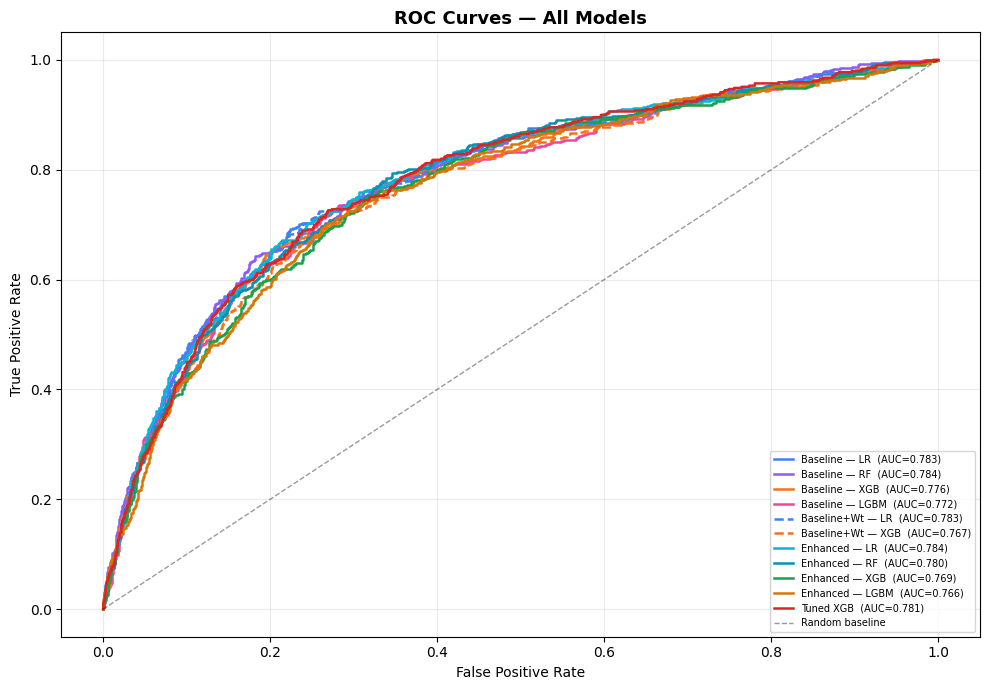

In [26]:
# Each tuple: (label, true labels, predicted probabilities, color, linestyle)
roc_items = [
    # --- Baseline models (no weights) ---
    ("Baseline — LR", y_te_b, y_prob_lr_b, "#3b82f6", "-"),
    ("Baseline — RF", y_te_b, y_prob_rf_b, "#8b5cf6", "-"),
    ("Baseline — XGB", y_te_b, y_prob_xgb_b, "#f97316", "-"),
    ("Baseline — LGBM", y_te_b, y_prob_lgbm_b, "#ec4899", "-"),

    # --- Baseline models WITH weights (ablation) ---
    ("Baseline+Wt — LR", y_te_b, y_prob_lr_bw, "#3b82f6", "--"),
    ("Baseline+Wt — XGB", y_te_b, y_prob_xgb_bw, "#f97316", "--"),

    # --- Enhanced models ---
    ("Enhanced — LR", y_te_e, y_prob_lr_e, "#06b6d4", "-"),
    ("Enhanced — RF", y_te_e, y_prob_rf_e, "#0891b2", "-"),
    ("Enhanced — XGB", y_te_e, y_prob_xgb_e, "#16a34a", "-"),
    ("Enhanced — LGBM", y_te_e, y_prob_lgbm_e, "#d97706", "-"),

    # --- Tuned ---
    ("Tuned XGB", y_te_e, y_prob_xgb_tuned, "#dc2626", "-"),
]

fig, ax = plt.subplots(figsize=(10, 7))

for name, y_t, y_p, color, ls in roc_items:
    fpr, tpr, _ = roc_curve(y_t, y_p)
    auc = roc_auc_score(y_t, y_p)

    ax.plot(
        fpr,
        tpr,
        color=color,
        lw=1.8,
        linestyle=ls,
        label=f"{name}  (AUC={auc:.3f})"
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random baseline")

ax.set_title("ROC Curves — All Models", fontweight="bold", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=7, loc="lower right")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Precision-Recall Curves
All ModelsWith ~15% dropout prevalence, the Precision-Recall curve is often more informative than the ROC curve. It shows how well the model performs specifically on the minority class. A model with a high area under the PR curve is good at both identifying dropouts (recall) and making sure its flags are accurate (precision).

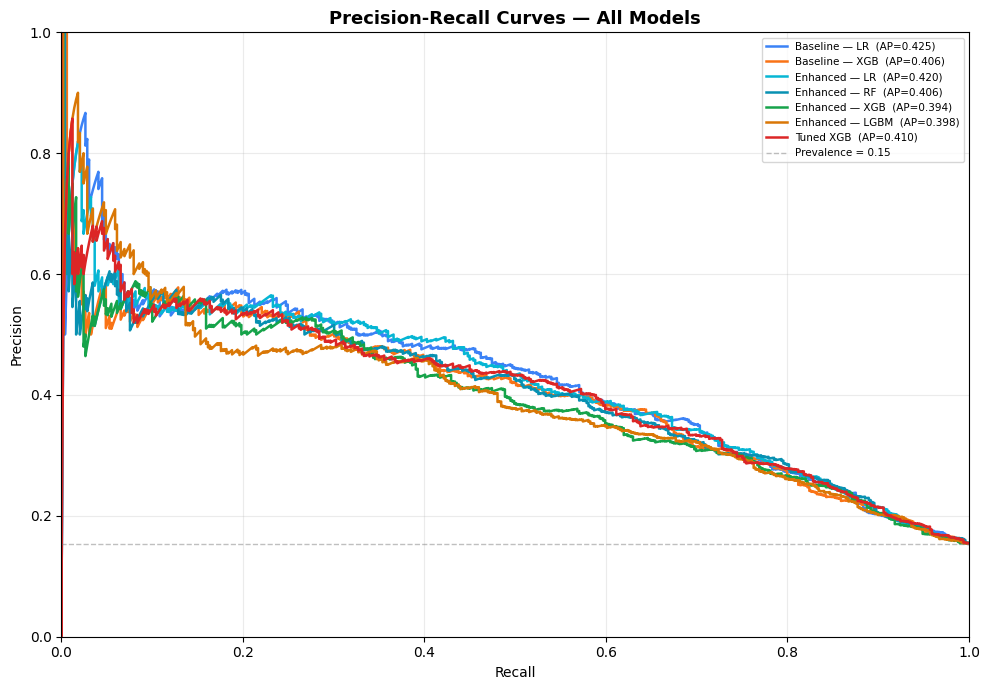

In [27]:
pr_items = [
    ("Baseline — LR", y_te_b, y_prob_lr_b, "#3b82f6"),
    ("Baseline — XGB", y_te_b, y_prob_xgb_b, "#f97316"),
    ("Enhanced — LR", y_te_e, y_prob_lr_e, "#06b6d4"),
    ("Enhanced — RF", y_te_e, y_prob_rf_e, "#0891b2"),
    ("Enhanced — XGB", y_te_e, y_prob_xgb_e, "#16a34a"),
    ("Enhanced — LGBM", y_te_e, y_prob_lgbm_e, "#d97706"),
    ("Tuned XGB", y_te_e, y_prob_xgb_tuned, "#dc2626"),
]

fig, ax = plt.subplots(figsize=(10, 7))

for name, y_t, y_p, color in pr_items:
    prec_vals, rec_vals, _ = precision_recall_curve(y_t, y_p)
    ap = average_precision_score(y_t, y_p)

    ax.plot(
        rec_vals,
        prec_vals,
        color=color,
        lw=1.8,
        label=f"{name}  (AP={ap:.3f})"
    )

# Baseline = prevalence rate
prevalence = y_te_e.mean()
ax.axhline(
    prevalence,
    color="gray",
    ls="--",
    lw=1,
    alpha=0.5,
    label=f"Prevalence = {prevalence:.2f}"
)

ax.set_title("Precision-Recall Curves — All Models", fontweight="bold", fontsize=13)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7.5, loc="upper right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Threshold Optimization Enhanced XGBoost
Rather than only testing t=0.50 and t=0.30, we sweep across a full range of thresholds to find the optimal operating point. This plot shows how Recall, Precision, and F1 change as we adjust the decision threshold, helping us make a data-driven choice.

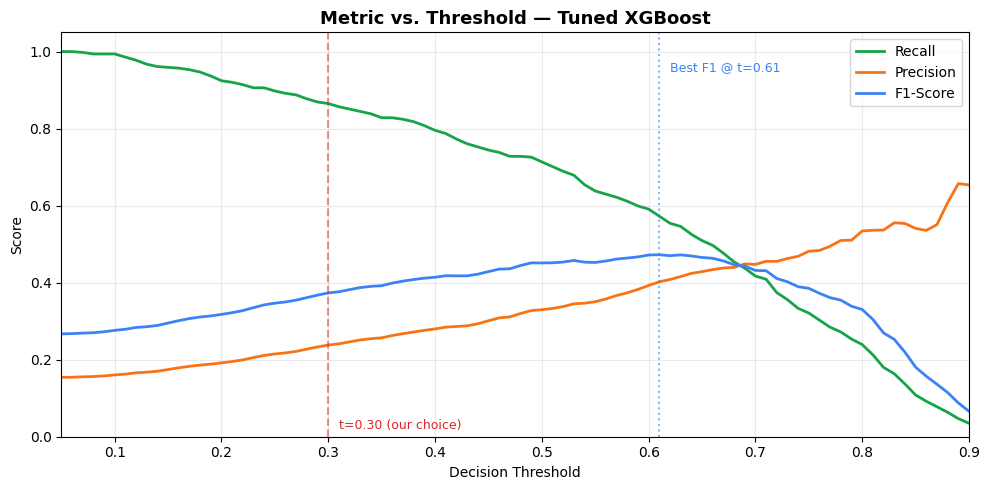

Threshold that maximises F1 : 0.61  (F1=0.4726, Recall=0.5726)
At t=0.30                    : F1=0.3733, Recall=0.8650


In [28]:
# Use the tuned model's probabilities for the threshold sweep
thresholds = np.arange(0.05, 0.95, 0.01)
recalls, precisions, f1s = [], [], []

for t in thresholds:
    y_t_pred = (y_prob_xgb_tuned >= t).astype(int)

    if y_t_pred.sum() == 0:
        recalls.append(0)
        precisions.append(0)
        f1s.append(0)
        continue

    recalls.append(recall_score(y_te_e, y_t_pred))
    precisions.append(precision_score(y_te_e, y_t_pred))
    f1s.append(f1_score(y_te_e, y_t_pred))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, recalls, color="#16a34a", lw=2, label="Recall")
ax.plot(thresholds, precisions, color="#f97316", lw=2, label="Precision")
ax.plot(thresholds, f1s, color="#3b82f6", lw=2, label="F1-Score")

# Mark the optimal F1 threshold
best_f1_idx = np.argmax(f1s)
best_t = thresholds[best_f1_idx]

ax.axvline(best_t, color="#3b82f6", ls=":", alpha=0.6)
ax.text(best_t + 0.01, 0.95, f"Best F1 @ t={best_t:.2f}", fontsize=9, color="#3b82f6")

# Mark the chosen 0.30 threshold
ax.axvline(0.30, color="#dc2626", ls="--", alpha=0.5)
ax.text(0.31, 0.02, "t=0.30 (our choice)", fontsize=9, color="#dc2626")

ax.set_title("Metric vs. Threshold — Tuned XGBoost", fontweight="bold", fontsize=13)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
ax.set_xlim([0.05, 0.90])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(
    f"Threshold that maximises F1 : {best_t:.2f}  "
    f"(F1={f1s[best_f1_idx]:.4f}, Recall={recalls[best_f1_idx]:.4f})"
)

t_030_idx = np.where(np.isclose(thresholds, 0.30))[0][0]
print(
    f"At t=0.30                    : "
    f"F1={f1s[t_030_idx]:.4f}, Recall={recalls[t_030_idx]:.4f}"
)

### Confusion Matrices — All Models

These confusion matrices (generated by the code below) give us a detailed breakdown of how each model performed. You can see the True Positives (TP - correct dropouts), False Negatives (FN - missed dropouts), False Positives (FP - falsely flagged), and True Negatives (TN - correct non-dropouts). Each matrix is color-coded for clarity.

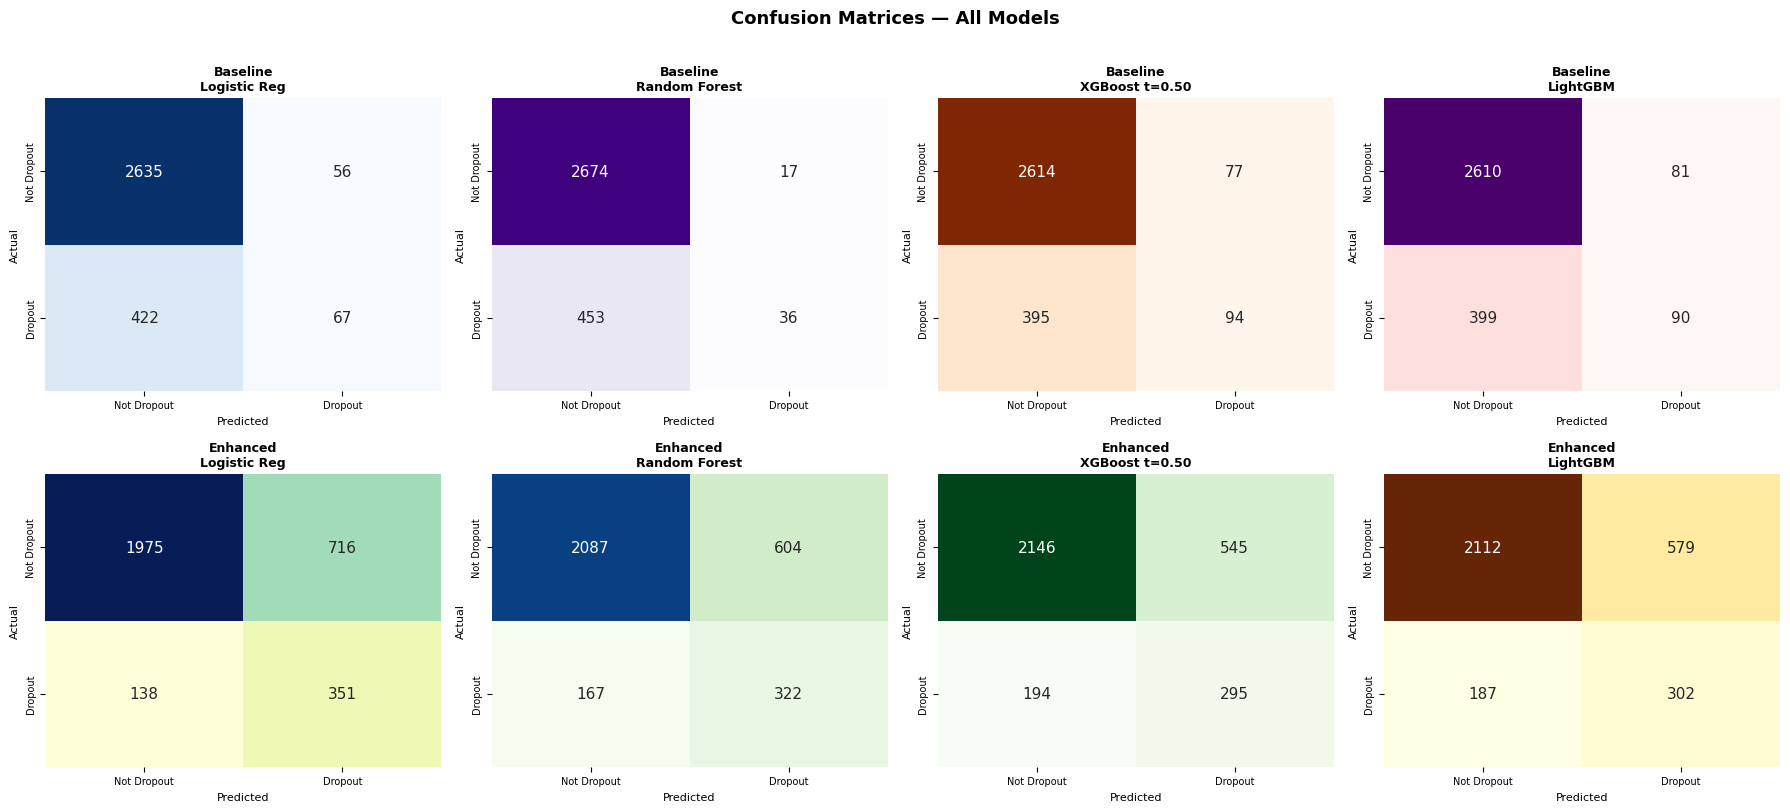

In [29]:
cm_items = [
    # (title, true labels, predicted labels, colormap)
    ('Baseline\nLogistic Reg',        y_te_b, y_pred_lr_b,    'Blues'),
    ('Baseline\nRandom Forest',        y_te_b, y_pred_rf_b,    'Purples'),
    ('Baseline\nXGBoost t=0.50',       y_te_b, y_pred_xgb_b50, 'Oranges'),
    ('Baseline\nLightGBM',             y_te_b, y_pred_lgbm_b,  'RdPu'),
    ('Enhanced\nLogistic Reg',         y_te_e, y_pred_lr_e,    'YlGnBu'),
    ('Enhanced\nRandom Forest',        y_te_e, y_pred_rf_e,    'GnBu'),
    ('Enhanced\nXGBoost t=0.50',       y_te_e, y_pred_xgb_e50, 'Greens'),
    ('Enhanced\nLightGBM',             y_te_e, y_pred_lgbm_e,  'YlOrBr'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
labels = ['Not Dropout', 'Dropout']

for ax, (title, y_t, y_p, cmap) in zip(axes, cm_items):
    cm = confusion_matrix(y_t, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                cbar=False, annot_kws={'size': 11},
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Confusion Matrices — All Models', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Feature Importance Tree-Based Models (including LightGBM)
Since Random Forest, XGBoost, and LightGBM are all tree-based, they can tell us which features were most important for their predictions. The code below generates bar charts showing the feature importance for each model across both datasets. Features in the model's colour are more important, while dimmed ones are less so.

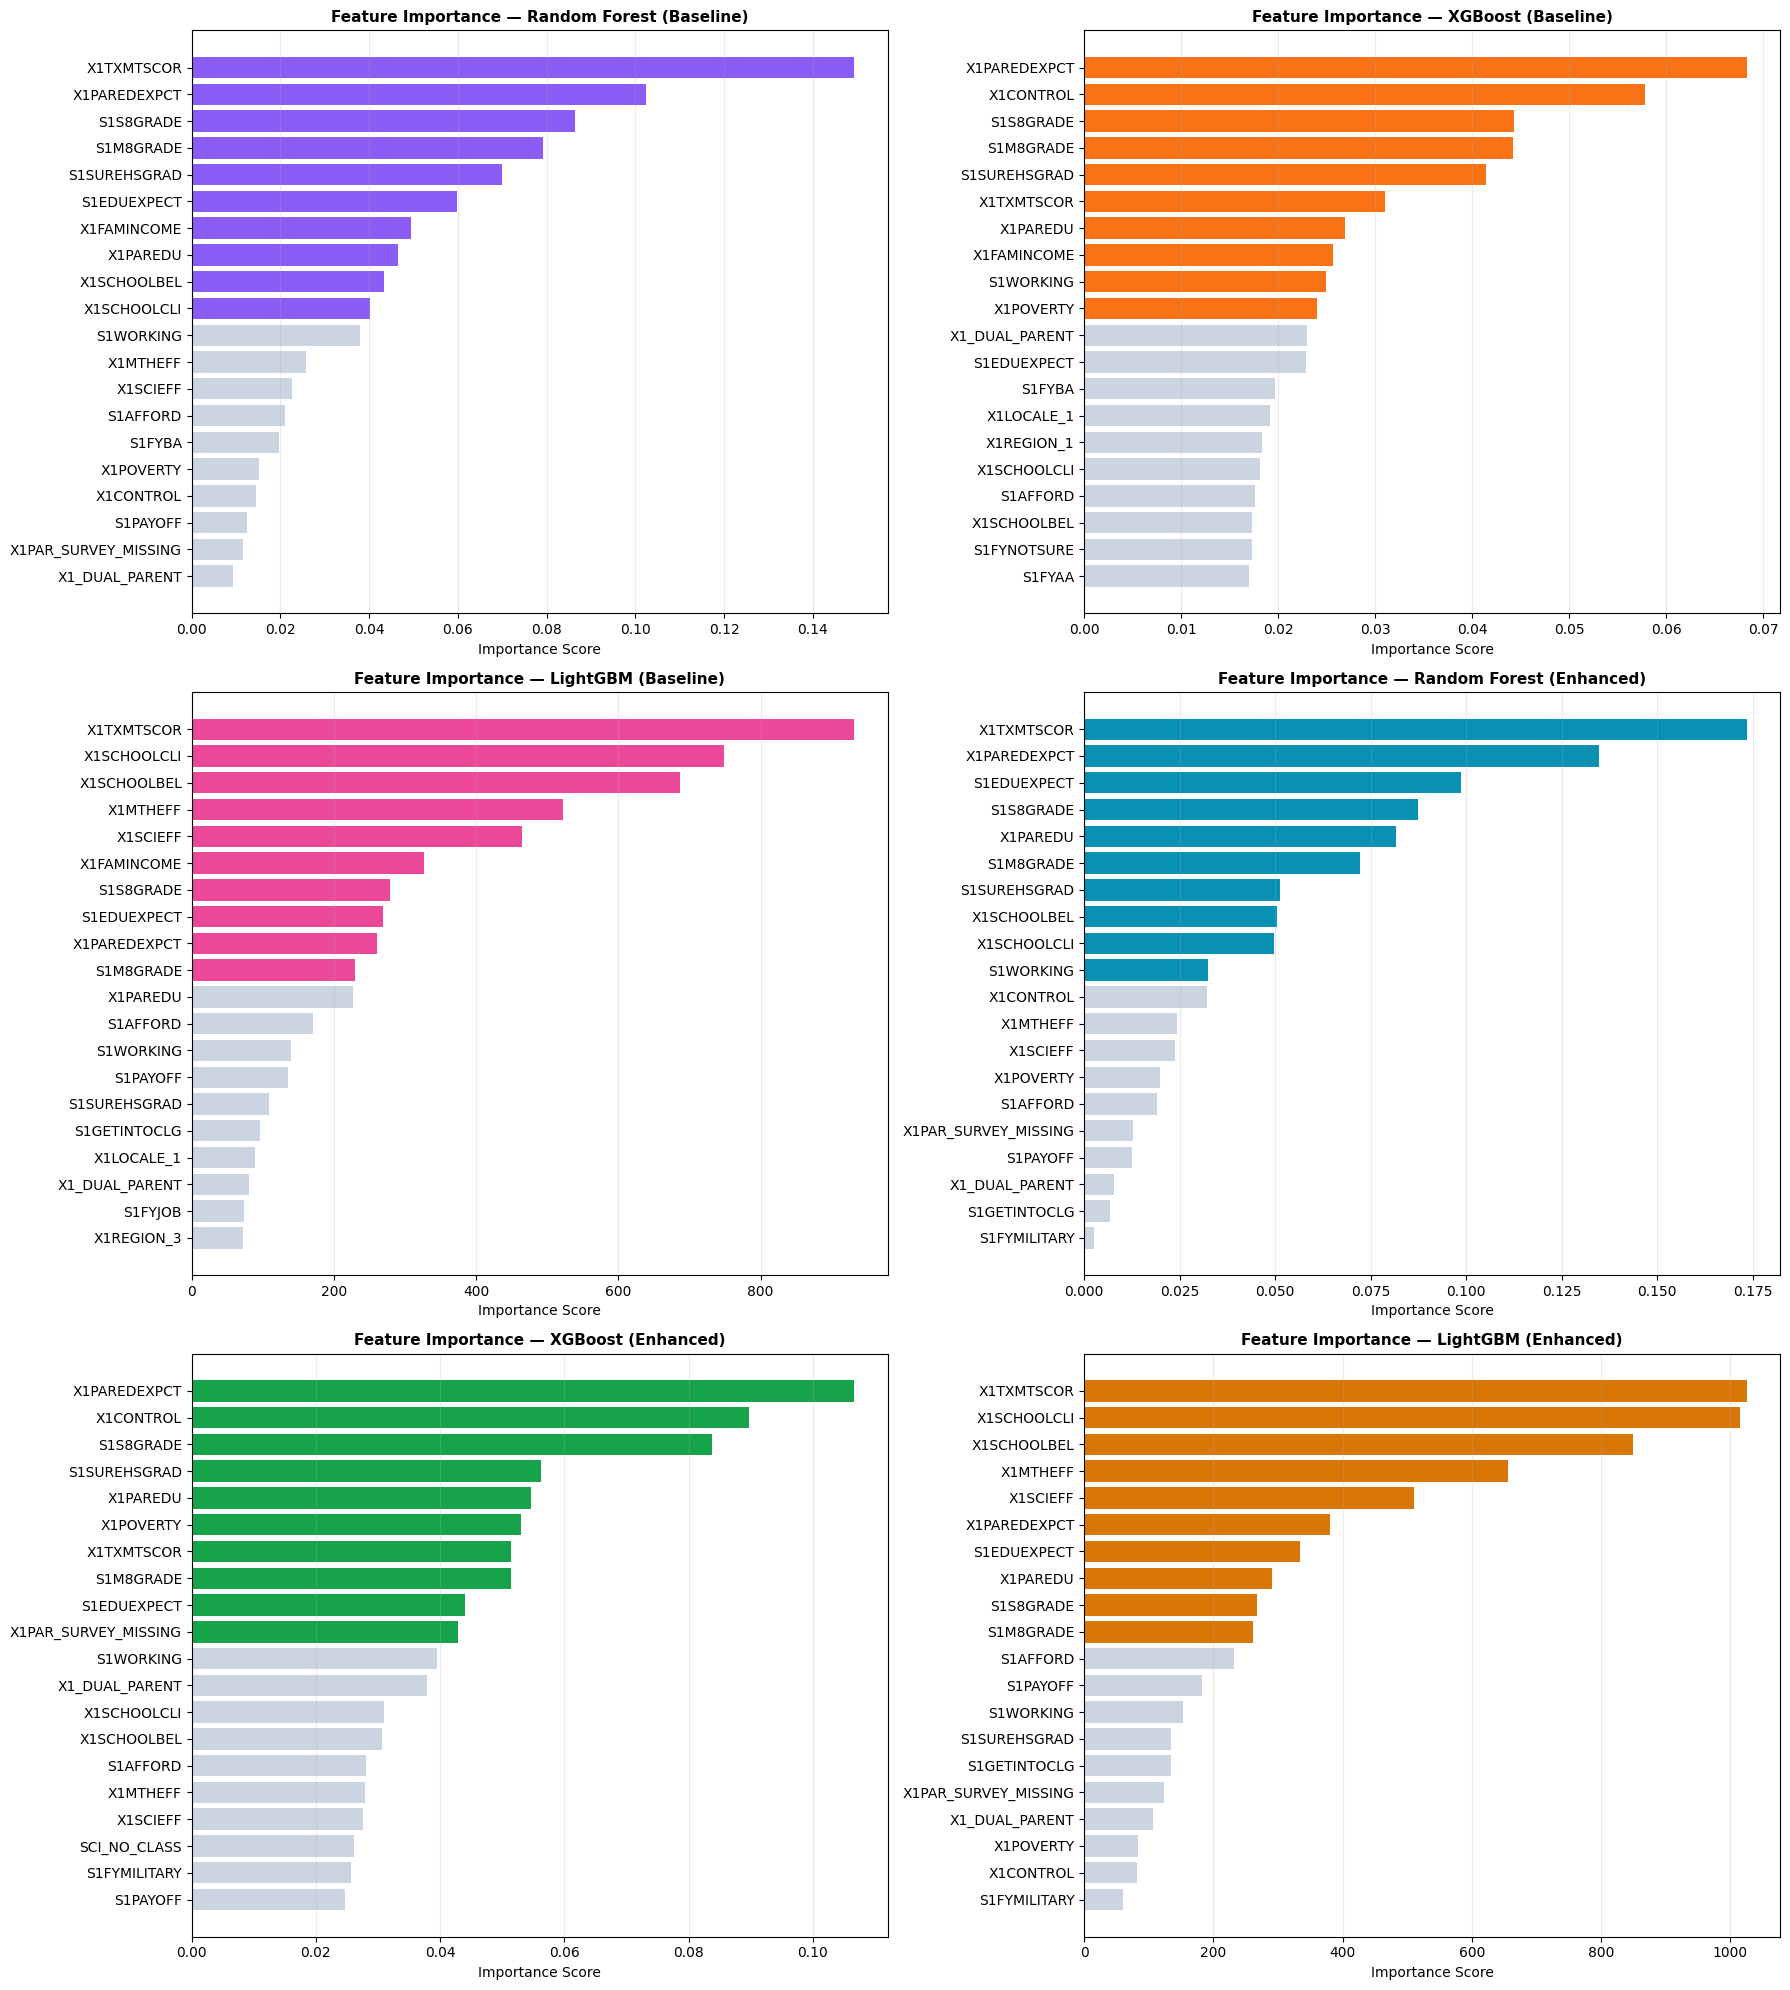

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
axes = axes.flatten()

tree_models = [
    (rf_base, FEATURES_BASE, "Random Forest (Baseline)", "#8b5cf6"),
    (xgb_base, FEATURES_BASE, "XGBoost (Baseline)", "#f97316"),
    (lgbm_base, FEATURES_BASE, "LightGBM (Baseline)", "#ec4899"),
    (rf_enh, FEATURES_ENH, "Random Forest (Enhanced)", "#0891b2"),
    (xgb_enh, FEATURES_ENH, "XGBoost (Enhanced)", "#16a34a"),
    (lgbm_enh, FEATURES_ENH, "LightGBM (Enhanced)", "#d97706"),
]

for ax, (model, features, name, color) in zip(axes, tree_models):
    fi = pd.DataFrame({
        "Feature": features,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=True)

    # Show top 20 features only for readability when there are many
    if len(fi) > 20:
        fi = fi.tail(20)

    bar_colors = [
        color if v >= fi["Importance"].median() else "#cbd5e1"
        for v in fi["Importance"]
    ]

    ax.barh(fi["Feature"], fi["Importance"], color=bar_colors, edgecolor="none")
    ax.set_title(f"Feature Importance — {name}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Importance Score")
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### SHAP Analysis Enhanced XGBoost (Best Model)
SHAP (SHapley Additive exPlanations) gives us a principled way to understand which features drive individual predictions and overall model behaviour. Unlike impurity-based feature importance, SHAP values are unbiased and can show the *direction* of each feature's effect (e.g., higher GPA → lower dropout risk). This directly answers our research question about which categories of student-level factors matter most.

Computing SHAP values (this may take a moment) ...


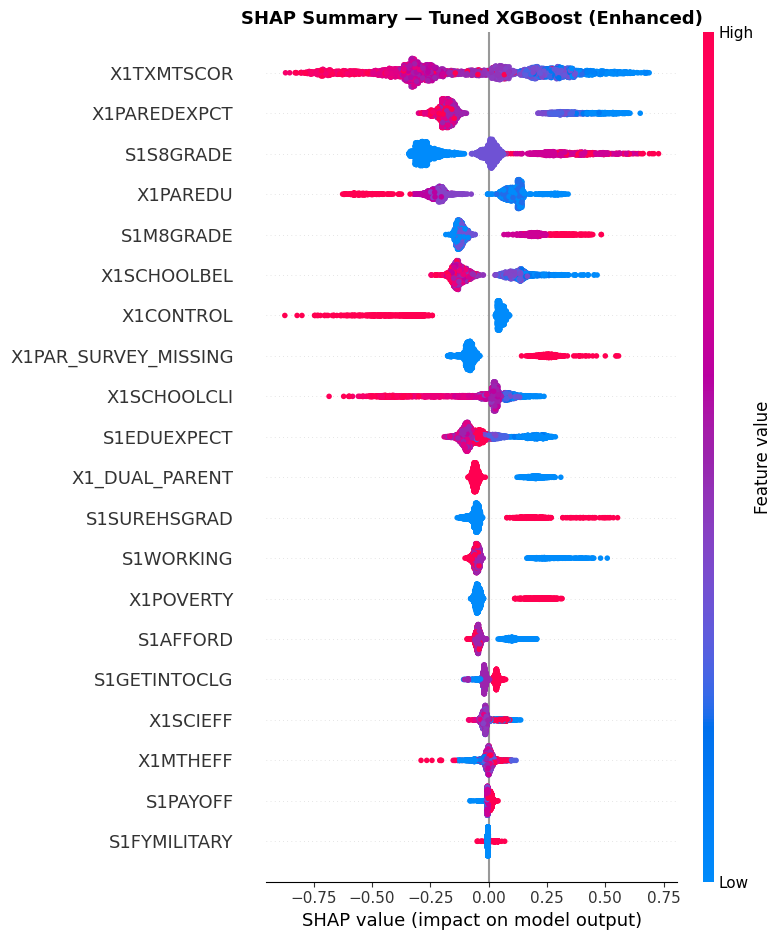

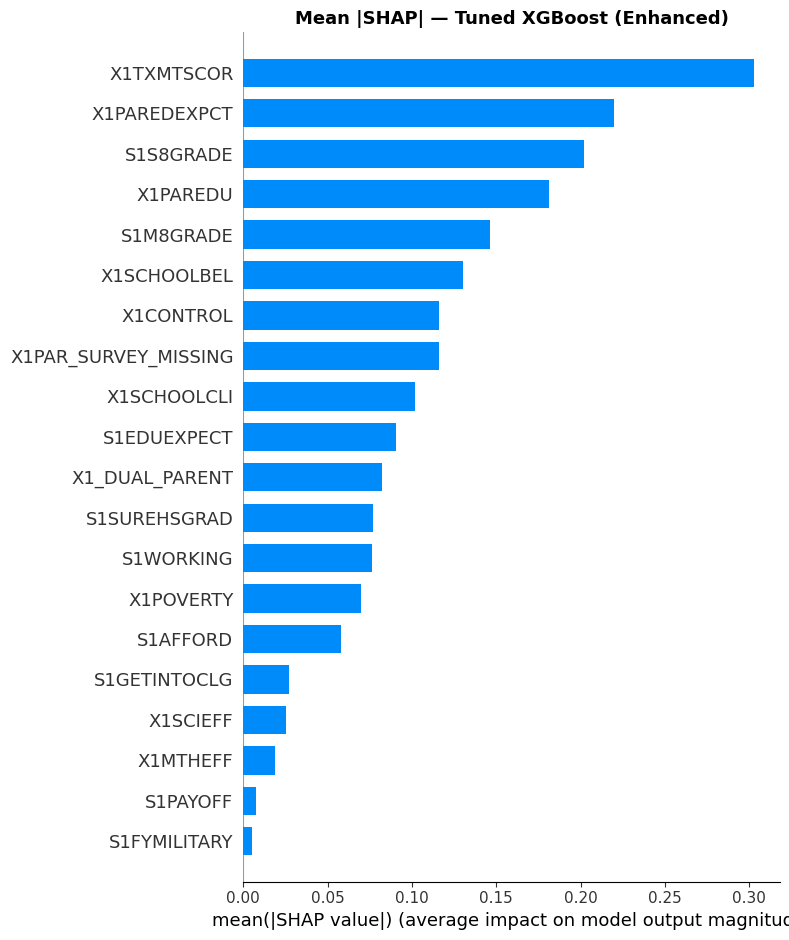

SHAP analysis complete.


In [31]:
# Use the tuned XGBoost model for SHAP analysis
print("Computing SHAP values (this may take a moment) ...")

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_te_e_sc)

# --- Summary plot (global feature importance with direction) ---
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_te_e_sc,
    feature_names=FEATURES_ENH,
    max_display=20,
    show=False
)
plt.title("SHAP Summary — Tuned XGBoost (Enhanced)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

# --- Bar plot (mean absolute SHAP) ---
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_te_e_sc,
    feature_names=FEATURES_ENH,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Mean |SHAP| — Tuned XGBoost (Enhanced)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("SHAP analysis complete.")

## Cross-Validation Baseline and Enhanced Models
To get a more reliable estimate of performance and to **fairly compare baseline vs. enhanced datasets**, we run 5-fold stratified cross-validation on **both** datasets. This gives us mean performance with standard deviations, making it clear whether the enhanced dataset truly improves prediction or whether the difference falls within sampling noise.

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_all_models = [
    # --- Baseline (no weights) ---
    ("Baseline — LR", lr_base, X_tr_b_sc, y_tr_b),
    ("Baseline — RF", rf_base, X_tr_b_sc, y_tr_b),
    ("Baseline — XGB", xgb_base, X_tr_b_sc, y_tr_b),
    ("Baseline — LGBM", lgbm_base, X_tr_b_sc, y_tr_b),

    # --- Enhanced (with weights) ---
    ("Enhanced — LR", lr_enh, X_tr_e_sc, y_tr_e),
    ("Enhanced — RF", rf_enh, X_tr_e_sc, y_tr_e),
    ("Enhanced — XGB", xgb_enh, X_tr_e_sc, y_tr_e),
    ("Enhanced — LGBM", lgbm_enh, X_tr_e_sc, y_tr_e),

    # --- Tuned ---
    ("Tuned XGB", xgb_tuned, X_tr_e_sc, y_tr_e),
]

print("5-Fold Stratified Cross-Validation — All Models")
print(f'{"Model":<25} {"ROC-AUC":>18} {"F1":>18} {"Recall":>18}')
print("-" * 82)

for name, model, X_cv, y_cv in cv_all_models:
    roc_cv = cross_val_score(model, X_cv, y_cv, cv=cv, scoring="roc_auc")
    f1_cv = cross_val_score(model, X_cv, y_cv, cv=cv, scoring="f1")
    rec_cv = cross_val_score(model, X_cv, y_cv, cv=cv, scoring="recall")

    print(
        f"{name:<25} "
        f"{roc_cv.mean():.4f} ± {roc_cv.std():.3f}  "
        f"{f1_cv.mean():.4f} ± {f1_cv.std():.3f}  "
        f"{rec_cv.mean():.4f} ± {rec_cv.std():.3f}"
    )

5-Fold Stratified Cross-Validation — All Models
Model                                ROC-AUC                 F1             Recall
----------------------------------------------------------------------------------
Baseline — LR             0.7907 ± 0.011  0.2601 ± 0.010  0.1663 ± 0.007
Baseline — RF             0.7913 ± 0.008  0.1361 ± 0.011  0.0757 ± 0.007
Baseline — XGB            0.7843 ± 0.011  0.2893 ± 0.010  0.1955 ± 0.007
Baseline — LGBM           0.7847 ± 0.011  0.2958 ± 0.016  0.2016 ± 0.017
Enhanced — LR             0.7883 ± 0.009  0.4404 ± 0.005  0.7175 ± 0.010
Enhanced — RF             0.7858 ± 0.010  0.4476 ± 0.019  0.6607 ± 0.020
Enhanced — XGB            0.7780 ± 0.012  0.4439 ± 0.019  0.6100 ± 0.029
Enhanced — LGBM           0.7780 ± 0.014  0.4490 ± 0.021  0.6305 ± 0.027
Tuned XGB                 0.7908 ± 0.011  0.4444 ± 0.016  0.7185 ± 0.026


## Probability Calibration Best Model
Our proposal promises a model that outputs a **calibrated probability score** between 0 and 1. Raw model probabilities can be over- or under-confident. We use `CalibratedClassifierCV` (Platt scaling) to calibrate the tuned XGBoost, then plot a reliability diagram to verify that the output probabilities are meaningful — i.e., students assigned a 30% risk score truly drop out ~30% of the time.


Calibrating the Tuned XGBoost model ...
  Calibrated XGBoost (t=0.30)
  Threshold used : 0.30
  Recall    : 0.4867   <-- fraction of real dropouts we caught
  F1-Score  : 0.4626   <-- balance between precision and recall
  ROC-AUC   : 0.7816   <-- ranking ability across all thresholds
  Precision : 0.4407
  Accuracy  : 0.8261   (not very meaningful here — classes are imbalanced)
  TP: 238  FN: 251  FP: 302  TN: 2389

              precision    recall  f1-score   support

 Not Dropout       0.90      0.89      0.90      2691
     Dropout       0.44      0.49      0.46       489

    accuracy                           0.83      3180
   macro avg       0.67      0.69      0.68      3180
weighted avg       0.83      0.83      0.83      3180



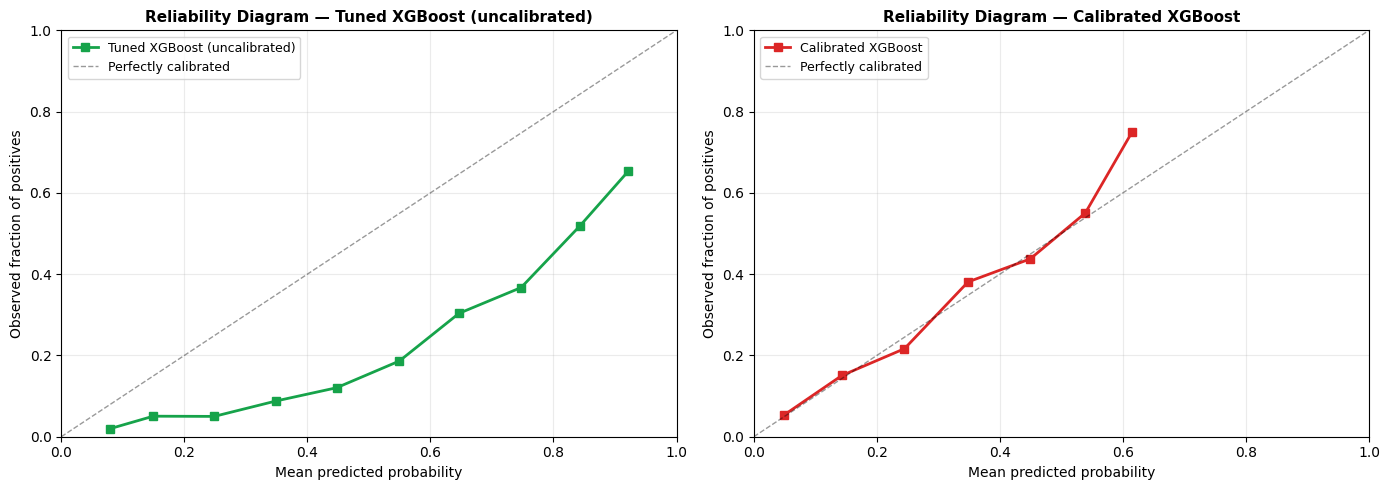

Calibration complete — the model now outputs meaningful probability scores.


In [33]:
# Calibrate the tuned XGBoost using 5-fold cross-validation on the training set
print("Calibrating the Tuned XGBoost model ...")

calibrated_xgb = CalibratedClassifierCV(
    xgb_tuned,
    method="sigmoid",   # Platt scaling
    cv=5
)

calibrated_xgb.fit(X_tr_e_sc, y_tr_e)

y_prob_calibrated = calibrated_xgb.predict_proba(X_te_e_sc)[:, 1]
y_pred_cal_30 = (y_prob_calibrated >= 0.30).astype(int)

evaluate(
    "Calibrated XGBoost (t=0.30)",
    y_te_e,
    y_pred_cal_30,
    y_prob_calibrated,
    threshold=0.30
)

# --- Reliability diagram (calibration curve) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, probs, color) in zip(
    axes,
    [
        ("Tuned XGBoost (uncalibrated)", y_prob_xgb_tuned, "#16a34a"),
        ("Calibrated XGBoost", y_prob_calibrated, "#dc2626"),
    ]
):
    fraction_pos, mean_pred = calibration_curve(
        y_te_e,
        probs,
        n_bins=10,
        strategy="uniform"
    )

    ax.plot(mean_pred, fraction_pos, "s-", color=color, lw=2, label=label)
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Perfectly calibrated")
    ax.set_title(f"Reliability Diagram — {label}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed fraction of positives")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("Calibration complete — the model now outputs meaningful probability scores.")

## Learning Curve Best Model
The learning curve shows how model performance changes as we increase the amount of training data. If the curves are still converging, more data would help. If they've plateaued, our current dataset size is sufficient. This is useful context for stakeholders considering whether to invest in larger data collection efforts.

Computing learning curve for Tuned XGBoost ...


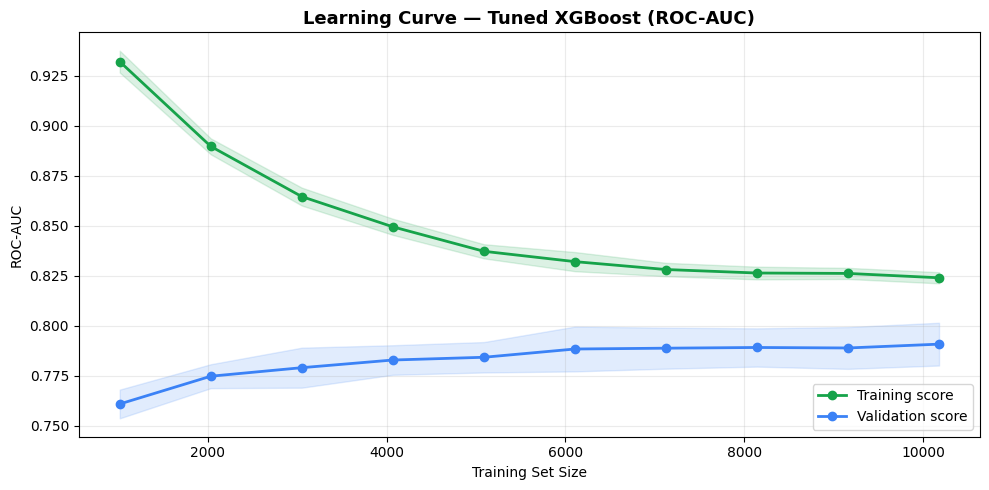

Final validation AUC at full training size: 0.7908 ± 0.011


In [34]:
print("Computing learning curve for Tuned XGBoost ...")

train_sizes, train_scores, val_scores = learning_curve(
    xgb_tuned,
    X_tr_e_sc,
    y_tr_e,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color="#16a34a"
)

ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color="#3b82f6"
)

ax.plot(train_sizes, train_mean, "o-", color="#16a34a", lw=2, label="Training score")
ax.plot(train_sizes, val_mean, "o-", color="#3b82f6", lw=2, label="Validation score")

ax.set_title("Learning Curve — Tuned XGBoost (ROC-AUC)", fontweight="bold", fontsize=13)
ax.set_xlabel("Training Set Size")
ax.set_ylabel("ROC-AUC")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Final validation AUC at full training size: {val_mean[-1]:.4f} ± {val_std[-1]:.3f}")

## Final Comparison Table

This table (generated by the code below) brings everything together! It shows the key metrics for all 10 models we've trained (4 baseline, 4 enhanced, and 2 extra XGBoost entries with threshold 0.30). We'll pay most attention to **Recall**, **F1-Score**, and **ROC-AUC**, as Accuracy can be misleading with imbalanced data.

In [35]:
display_cols = [
    "Model", "Threshold", "Recall", "F1", "ROC-AUC",
    "Precision", "Accuracy", "TP", "FN", "FP", "TN"
]

summary_df = pd.DataFrame(results)[display_cols].copy()

# Preserve a logical order
model_order = [
    "Baseline 1 — Logistic Regression",
    "Baseline 2 — Random Forest",
    "Baseline 3 — XGBoost (t=0.50)",
    "Baseline 3 — XGBoost (t=0.30)",
    "Baseline 4 — LightGBM",
    "Baseline 1w — LR + weights",
    "Baseline 2w — RF + weights",
    "Baseline 3w — XGB + weights",
    "Baseline 4w — LGBM + weights",
    "Enhanced 1 — Logistic Regression",
    "Enhanced 2 — Random Forest",
    "Enhanced 3 — XGBoost (t=0.50)",
    "Enhanced 3 — XGBoost (t=0.30)",
    "Enhanced 4 — LightGBM",
    "Tuned XGBoost (t=0.50)",
    "Tuned XGBoost (t=0.30)",
    "Calibrated XGBoost (t=0.30)",
]

order_map = {name: i for i, name in enumerate(model_order)}

summary_df["_order"] = summary_df["Model"].map(order_map).fillna(99)
summary_df = (
    summary_df
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)

summary_df.index += 1

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("FINAL MODEL COMPARISON")
print("Rows 1-5: Baseline (no weights)  |  Rows 6-9: Baseline + weights (ablation)")
print("Rows 10-14: Enhanced + weights   |  Rows 15-17: Tuned & Calibrated")
print("Primary metrics: Recall, F1, ROC-AUC  (Accuracy is misleading under class imbalance)")
print()
print(summary_df.to_string())

FINAL MODEL COMPARISON
Rows 1-5: Baseline (no weights)  |  Rows 6-9: Baseline + weights (ablation)
Rows 10-14: Enhanced + weights   |  Rows 15-17: Tuned & Calibrated
Primary metrics: Recall, F1, ROC-AUC  (Accuracy is misleading under class imbalance)

                               Model  Threshold  Recall      F1  ROC-AUC  Precision  Accuracy   TP   FN    FP    TN
1   Baseline 1 — Logistic Regression        0.5  0.1370  0.2190   0.7835     0.5447    0.8497   67  422    56  2635
2         Baseline 2 — Random Forest        0.5  0.0736  0.1328   0.7838     0.6792    0.8522   36  453    17  2674
3      Baseline 3 — XGBoost (t=0.50)        0.5  0.1922  0.2848   0.7759     0.5497    0.8516   94  395    77  2614
4      Baseline 3 — XGBoost (t=0.30)        0.3  0.4315  0.4355   0.7759     0.4396    0.8280  211  278   269  2422
5              Baseline 4 — LightGBM        0.5  0.1840  0.2727   0.7723     0.5263    0.8491   90  399    81  2610
6         Baseline 1w — LR + weights        0.5  0.7

## Pipeline Documentation

This section summarizes the key aspects of our dropout prediction project.

---

## 1. Problem Definition

**Task:** Binary classification (`dropout` vs. `not dropout`)  
**Target:** `X4EVERDROP`  
- `1` = dropped out  
- `0` = did not drop out  

**Data Source:** HSLS:09 (High School Longitudinal Study of 2009) (Wave 1)  
**Population:** 9th-grade students in the United States  

**Primary Metric:** **Recall**

Recall is the main metric because, in an early-intervention setting, missing an at-risk student (**false negative**) is more costly than flagging a student who may not eventually drop out (**false positive**).

> **Interpretation of Recall:**  
> “Of all students who actually dropped out, how many did the model successfully identify?”

---

## 2. Datasets

We worked with two datasets:

### Baseline Dataset
`Baseline_Dataset50.csv`  
- Contains **50 features**
- Built exclusively from **9th-grade (base-year)** data

### Enhanced Dataset
`Wave1_FeatureSelected.csv`  
- Feature selection was implemented.
- Enables a comparison between **earlier prediction** and **later, richer prediction**

### Pre-processing Before This Notebook
- One-hot encoding was applied to categorical variables
- Missing values were handled using principled imputation strategies
- Restricted-use suppressed variables and irrelevant columns were removed

### Pre-processing Inside This Notebook
- `StandardScaler` was applied to features
- Data was split into **80/20 train/test sets**
- Stratification was used to preserve the original dropout class distribution

---

## 3. Class Imbalance

The target variable is imbalanced:

- **Not Dropout:** ~84.6% (~13,457 students)
- **Dropout:** ~15.4% (~2,443 students)
- **Class Ratio:** about **5.5 non-dropouts for every 1 dropout**

### Handling Strategy
For the **enhanced models**, class imbalance was addressed using:
- `class_weight='balanced'` for sklearn models
- `scale_pos_weight` for XGBoost and LightGBM

For the **baseline models**, we trained:
- versions **without** class weights
- versions **with** class weights

This acts as an **ablation study**, helping isolate whether performance gains come from:
1. class weighting, or
2. the richer enhanced feature set

---

## 4. Models Evaluated

We compared four core model families across both datasets, then added a tuned and calibrated final model.

### Core Models
- **Logistic Regression**  
  Linear baseline; interpretable, fast, and useful for establishing a reference point

- **Random Forest**  
  Tree ensemble that captures non-linear relationships and feature interactions

- **XGBoost**  
  Regularized gradient boosting; strongest overall performer in our experiments

- **LightGBM**  
  Efficient leaf-wise gradient boosting; fast alternative to XGBoost with comparable performance

### Final Extended Models
- **Tuned XGBoost**  
  Hyperparameters optimized using `RandomizedSearchCV` with 40 iterations

- **Calibrated XGBoost**  
  Tuned XGBoost followed by Platt scaling for better probability calibration

---

## 5. Decision Threshold Strategy

We evaluated two decision thresholds:

### Threshold = 0.50
- Standard default threshold
- Produces fewer false positives
- More suitable when intervention resources are very limited

### Threshold = 0.30
- Lower threshold
- Increases recall substantially
- Flags more students as at-risk
- Better suited to **early intervention** settings where missing a dropout is more serious than issuing extra alerts

A threshold sweep from **0.05 to 0.90** was also conducted to compare this choice against the threshold that maximizes F1-score.

---

## 6. Evaluation Metrics

### Primary Metric
- **Recall**  
  Fraction of actual dropouts correctly identified

### Secondary Metrics
- **F1-Score**  
  Harmonic mean of precision and recall; useful for balancing both

- **ROC-AUC**  
  Measures ranking ability across all thresholds; threshold-independent

- **Precision**  
  Fraction of flagged students who are actually dropouts

- **Accuracy**  
  Included for completeness, but **not reliable here** because of class imbalance

> A model that predicts “no dropout” for everyone would still achieve about **85% accuracy**, despite being useless for intervention.

---

## 7. Ablation Study

### Goal
To determine whether recall improvements were driven by:
- **class weighting**, or
- **enhanced features**

### Setup
Baseline models were run:
- first **without weights**
- then **with weights**

This lets us decompose performance improvements as follows:

- **Effect of class weights alone**  
  = `Baseline+Weights Recall − Baseline Recall`

- **Effect of enhanced features alone**  
  = `Enhanced Recall − Baseline+Weights Recall`

---

## 8. Interpretability

To understand model behavior, we used two interpretability approaches:

### Tree-Based Feature Importance
Computed for:
- Random Forest
- XGBoost
- LightGBM

### SHAP Analysis
Computed for the best-performing model (**Tuned XGBoost**)

SHAP provides:
- **global importance rankings**
- **directional effects**, showing whether higher or lower values of a feature push predictions toward dropout or non-dropout

---

## 9. Calibration

The final model was calibrated using:

- `CalibratedClassifierCV`
- **Platt scaling** (`method='sigmoid'`)

### Why calibration matters
A calibrated probability should be interpretable.  
For example, if a student is assigned a **30% dropout probability**, then among students with similar scores, about **30% should actually drop out**.

Reliability diagrams were used to confirm calibration improvement.

---

## 10. Results Summary and Recommendation

Our modeling pipeline followed a deliberate progression across data horizons, imbalance-handling strategies, and model families.

### Step 1 — Baseline with Logistic Regression
Using 9th-grade data that's not properly cleaned, irrelevant features were included, and there were no class balancing,  
`Baseline 1 — Logistic Regression` achieved a recall of about **0.14**.

This shows that:
- a simple linear model
- trained on imbalanced base-year data  
is insufficient for identifying most at-risk students.

### Step 2 — Baseline Ablation with Class Weights
We re-ran baseline models with class weighting to measure how much recall improvement came from weighting alone.

### Step 3 — Enhanced Dataset + Class Balancing
Better feature selection was introduced here, in addition to enhanced cleaning after proper understanding of the features using EDA.
also applying class balancing significantly improved recall across model families.

### Step 4 — Hyperparameter Tuning + Calibration
The tuned and calibrated XGBoost model at **threshold = 0.30** emerged as the strongest final model.

### Final Recommendation
> **Recommended model:** Calibrated Tuned XGBoost at `t = 0.30`

This model offers:
- high recall
- interpretable predictions via SHAP
- calibrated probability outputs

### Deployment Note
If counselor or intervention capacity is limited, the threshold can be raised to around **0.40–0.45** to reduce the number of flagged students while still maintaining much better recall than the baseline.

---

## 11. Reproducibility and Leakage Prevention

To ensure reproducibility and avoid leakage:

- `random_state=42` was used consistently across:
  - train/test splits
  - model initialization
  - hyperparameter search

- `StandardScaler` was fit **only on the training data**
- The test set was **never used** during:
  - training
  - threshold selection
  - feature engineering

This ensures a valid and fair evaluation pipeline.